In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 5
NUM_CLASSES = 10

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [4]:
train_dataset = torchvision.datasets.MNIST(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

In [5]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [6]:
class CNNClassifier(nn.Module):
    
    def __init__(self):
        super(CNNClassifier, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, NUM_CLASSES)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.pool(torch.relu(x))
        x = self.conv2(x)
        x = self.pool(torch.relu(x))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
model = CNNClassifier()
print(model)

CNNClassifier(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [8]:
criterion = nn.CrossEntropyLoss()

In [9]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [10]:
def train_model():
    
    train_losses = []
    
    for epoch in range(EPOCHS):

        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        
        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}")
    
    return train_losses

In [11]:
train_losses = train_model()

Epoch 1/5 - Loss: 0.1365
Epoch 2/5 - Loss: 0.0444
Epoch 3/5 - Loss: 0.0300
Epoch 4/5 - Loss: 0.0220
Epoch 5/5 - Loss: 0.0177


In [12]:
def evaluate_model():
    
    model.eval()
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        
        for images, labels in test_loader:
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    
    accuracy = 100 * correct / total
    
    print(f"\nTest Accuracy: {accuracy:.2f}%")
    
    return all_preds, all_labels

In [13]:
preds, labels = evaluate_model()


Test Accuracy: 98.90%


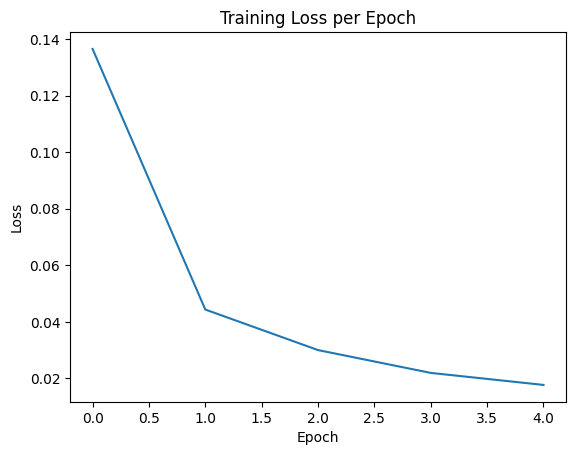

In [14]:
plt.plot(train_losses)
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [15]:
cm = confusion_matrix(labels, preds)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 978    0    0    0    0    0    0    0    1    1]
 [   2 1131    0    1    0    0    1    0    0    0]
 [   1    0 1023    1    0    0    0    6    1    0]
 [   0    1    1 1002    0    3    0    2    1    0]
 [   0    0    0    0  971    0    0    1    0   10]
 [   0    0    1   10    0  877    1    0    2    1]
 [  16    3    5    0   12    1  920    0    1    0]
 [   0    2    1    0    0    0    0 1020    1    4]
 [   1    0    2    1    0    1    0    1  965    3]
 [   0    0    0    0    3    1    0    0    2 1003]]


In [16]:
print("\nClassification Report:")
print(classification_report(labels, preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.98      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       1.00      0.96      0.98       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

